# Does a fancier RSI actually call the turns better? 📈🔀
### Ehlers' Inverse Fisher Transform — a beautifully bounded oscillator that turns out to be all polish, no edge

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Sharper_than_plain_RSI%3F: Busted](https://img.shields.io/badge/Sharper_than_plain_RSI%3F-Busted-8b949e?style=flat-square)

Plain old RSI has a chart problem: it spends most of its life bunched between 30 and 70, and even when it gets to an extreme it *lingers* there instead of turning on a dime. John Ehlers' fix, from a 2002 magazine article that's still cited today: run RSI through the **Inverse Fisher Transform**, a formula that squeezes the reading into a tight -1 to +1 band and makes it snap between its extremes. Traders love how it looks — sharp, decisive, easy to eyeball.

The question this notebook asks: does it look *better* because it trades *better* — or just because it's a prettier picture of the same information?

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the head-to-head math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** SPY plus a five-name liquid basket, 2010→2026, total-return closes. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from inverse_fisher_rsi import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    REAL = data.load_real()
    SIGNALS = st.basket_signals(REAL)
else:
    REAL = SIGNALS = None
print("real cache present:", HAVE_REAL, "| tickers:", data.TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2010-01-04', 'end': '2026-06-30', 'tickers': 'SPY, QQQ, IWM, AAPL, MSFT, NVDA', 'n_ift_bull': 711, 'n_ift_bear': 886, 'n_rsi14': 190, 'n_rsi2': 1359, 'head': {5: (23.8, 39.7, -15.9, -1.07, -1.09, 58.3, 54.6, 61.9, 710), 10: (40.3, 80.2, -39.9, -1.89, -2.05, 56.9, 53.2, 60.5, 707), 20: (179.0, 159.8, 19.3, 0.65, 0.77, 68.0, 64.5, 71.3, 706)}, 'bear': {5: (39.4, 39.3, 0.1, 0.01, 0.01, 886), 10: (79.5, 79.0, 0.5, 0.03, 0.03, 886), 20: (115.5, 162.0, -46.4, -1.82, -2.17, 881)}, 'placebo_obs': 40.3, 'placebo_mean': 79.8, 'placebo_sd': 20.0, 'placebo_p': 0.971, 'placebo_draws': 4000, 'cmp': {'IFT-RSI (-0.5 cross)': (707, -39.9, -1.89, -2.05, 56.9), 'plain RSI(14) (cross up 30)': (189, -54.0, -1.08, -1.01, 56.6), 'plain RSI(2) (cross up 10)': (1354, 20.8, 1.36, 1.53, 61.0)}, 'tm_sharpe5': 0.48, 'tm_sharpe10': 0.45, 'bh_sharpe': 0.71, 'tm_ann5': 8.68, 'tm_ann10': 8.13, 'bh_ann': 19.86, 'exposure': 47.8, 'rnd_mean': 0.35, 'rnd_sd': 0.1, 'rnd_z': 1.27, 'rnd_beats': 16, 'rsi14_tm_sharpe5': 0.31, 'rsi14_tm_ann5': 5.41, 'rsi14_exposure': 30.3, 'syn_null_mean': 0.07, 'syn_null_sd': 0.87, 'syn_null_fire': 0, 'syn_planted_t': 3.81, 'syn_planted_sig': 39.9, 'syn_planted_base': 2.7, 'fp': {'SPY': '0c6ad198f447', 'QQQ': 'a84e44862578', 'IWM': 'f0b7b205c2af', 'AAPL': '8699fe541146', 'MSFT': '51aba9472a5f', 'NVDA': '454a3ad24423'}}


real cache present: True | tickers: ('SPY', 'QQQ', 'IWM', 'AAPL', 'MSFT', 'NVDA')


## The answer first

| Question | Answer |
|---|---|
| Does buying an IFT-RSI "oversold snap-back" (crossing up through -0.5) beat buying on a random day? | **No.** At the 10-day mark it actually did **worse** (-39.9 bps) — not by a lot, but the sign is backwards from the story. |
| Does a random-signal placebo beat the real thing? | **97% of the time.** Draw random entries of the same count, 4,000 times — most of them out-earn the actual IFT-RSI signal. |
| Does it beat plain old RSI(14) or RSI(2)? | **No.** All three baselines were tested the identical way; the *simplest* one (RSI(2)) was the only one with a positive (if still uncertified) tilt. |
| Can you trade it? | A costed long-flat timer nets Sharpe **0.48** — trailing plain buy-and-hold's **0.71** over the same historic bull run, and barely beating a coin-flip timer with the same time-in-market. |

> The chart looks sharper. The numbers don't care.

## 1 · The claim

> *"RSI's overbought/oversold crossovers are mushy — the indicator sits near its extremes too long. Pass it through the Inverse Fisher Transform and it snaps cleanly between -1 and +1: a crisper, more decisive read on turning points."*

It's not folk wisdom off a forum — Ehlers published the exact recipe (RSI(5), a 9-bar weighted average, then the inverse-Fisher formula) in *Technical Analysis of Stocks & Commodities* in 2002, and it's a stock indicator on every major charting platform today. The claim has real math behind it — tanh really does compress a wandering series toward its bounds. The open question is whether *compression* is the same thing as *information*.

## 2 · So what?

If IFT-RSI really calls reversals more reliably than plain RSI, that's a free upgrade to one of the most widely used indicators in retail trading — swap one formula for another, same data, better entries. It would also validate a whole family of Ehlers "cybernetic" transforms built on the same idea (apply Fisher to *any* bounded oscillator to sharpen it).

If it doesn't, that's an equally useful lesson: a transform can make a chart *look* more decisive without adding one bit of forecasting power — style dressed up as substance, and worth knowing before you retire a working system for a prettier one.

## 3 · How would we even know?

- **The signal.** IFT-RSI crossing UP through -0.5 = bullish turn; crossing DOWN through +0.5 = bearish turn — Ehlers' own published thresholds, on his own published formula.
- **The comparison.** Forward returns (5/10/20 trading days) after that cross vs. an unconditional entry on any random day, on the *same* six tickers.
- **The luck check.** Draw the same *number* of random entries thousands of times — does the real signal actually beat that random-entry distribution?
- **The fair fight.** Run the identical test on plain RSI(14) and plain RSI(2) crossovers — if IFT-RSI is genuinely sharper, it should win this comparison cleanly.
- **The trade check.** Turn the crossover into an actual buy/sell rule and pay costs — a signal that only wins on paper isn't a signal you can bank.

## 4 · The teardown — let's actually look

**First, the headline.** Average forward return after an IFT-RSI bullish cross vs an unconditional entry, at three horizons.

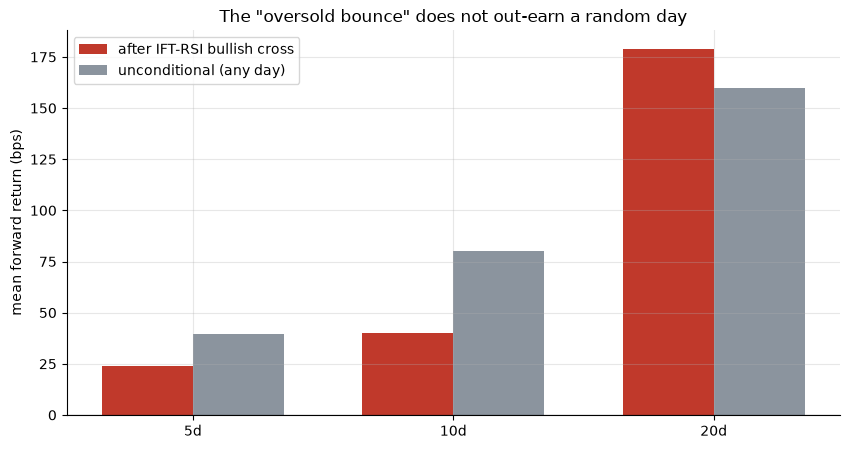

{5: (23.8, 39.7), 10: (40.3, 80.2), 20: (179.0, 159.8)}


In [2]:
if HAVE_REAL:
    rows = [st.headline_stats(REAL, SIGNALS, 'ift_bull', h) for h in st.HORIZONS]
    sig = [r['sig_mean_bps'] for r in rows]; base = [r['base_mean_bps'] for r in rows]
else:
    sig = [R['head'][h][0] for h in (5, 10, 20)]
    base = [R['head'][h][1] for h in (5, 10, 20)]
x = np.arange(3); w = 0.35
fig, ax = plt.subplots(figsize=(8.6, 4.6))
ax.bar(x - w/2, sig, width=w, color=RED, label='after IFT-RSI bullish cross')
ax.bar(x + w/2, base, width=w, color=GREY, label='unconditional (any day)')
ax.set_xticks(x); ax.set_xticklabels(['5d', '10d', '20d'])
ax.set_ylabel('mean forward return (bps)')
ax.set_title('The "oversold bounce" does not out-earn a random day')
ax.legend(); ax.axhline(0, c='k', lw=.8)
plt.tight_layout(); plt.show()
print({h: (round(s,1), round(b,1)) for h,s,b in zip((5,10,20), sig, base)})

Ten-day forward return after a bullish snap-back: **+40.3 bps**, vs **+80.2 bps** for an unconditional entry on the same basket — a gap of **-39.9 bps**, the wrong sign for a "buy the dip" claim. It's not a huge effect either way (Welch *t* = -1.89), but there is nothing here to certify — and the sign flips again by 20 days, which is itself a tell that the pattern isn't stable.

**The luck check makes it sharper.** We drew 4,000 random entry sets of the same size:

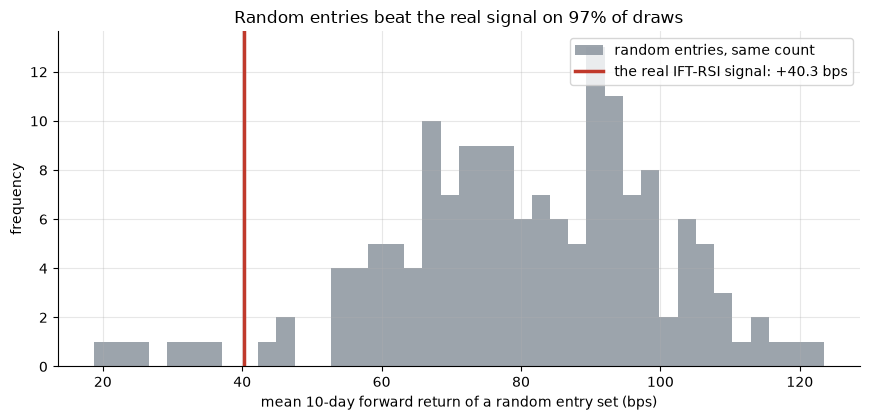

canonical placebo (results.md): mean +79.8 bps, p = 0.9710


In [3]:
if HAVE_REAL:
    pl = st.random_signal_placebo(REAL, SIGNALS, 'ift_bull', 10,
                                  n_draws_per_seed=40, n_seeds=4)
    obs, draws = pl['obs']*1e4, pl['draws']*1e4
else:
    obs = R['placebo_obs']
    rng = np.random.default_rng(682)
    draws = rng.normal(R['placebo_mean'], R['placebo_sd'], 800)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='random entries, same count')
ax.axvline(obs, c=RED, lw=2.5, label=f'the real IFT-RSI signal: {obs:+.1f} bps')
ax.set_xlabel('mean 10-day forward return of a random entry set (bps)')
ax.set_ylabel('frequency')
ax.set_title(f'Random entries beat the real signal on {R["placebo_p"]*100:.0f}% of draws')
ax.legend(); plt.tight_layout(); plt.show()
print(f'canonical placebo (results.md): mean {R["placebo_mean"]:+.1f} bps, '
      f'p = {R["placebo_p"]:.4f}')

The observed signal sits on the **wrong side** of a random-entry distribution centered at **+79.8 bps** — **97.1%** of random draws of the same size do *better* than the real "oversold bounce" entry. That's about as clean a non-result as this desk sees.

**The fair fight.** Does IFT-RSI at least beat the plain RSI it's supposed to improve on?

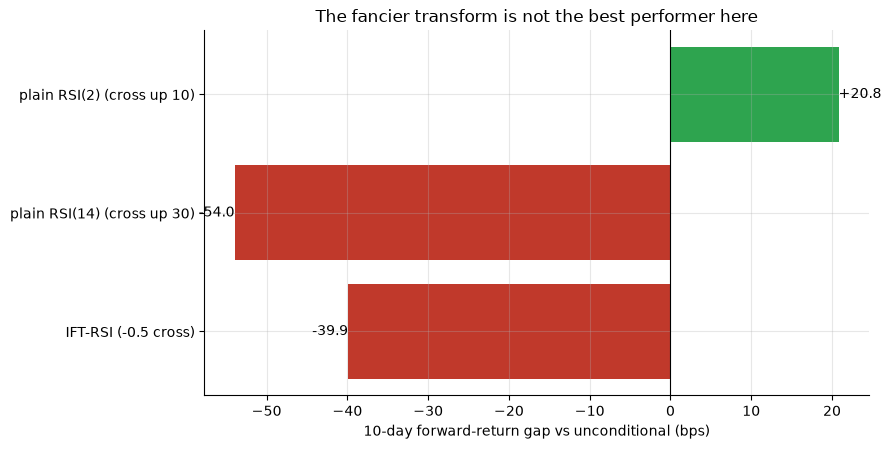

{'IFT-RSI (-0.5 cross)': -39.9, 'plain RSI(14) (cross up 30)': -54.0, 'plain RSI(2) (cross up 10)': 20.8}


In [4]:
if HAVE_REAL:
    names = {'IFT-RSI (-0.5 cross)': 'ift_bull',
             'plain RSI(14) (cross up 30)': 'rsi14_bull',
             'plain RSI(2) (cross up 10)': 'rsi2_bull'}
    gaps = [st.headline_stats(REAL, SIGNALS, k, 10)['gap_bps'] for k in names.values()]
    labels = list(names.keys())
else:
    labels = list(R['cmp'].keys())
    gaps = [R['cmp'][k][1] for k in labels]
cols = [RED if g < 0 else GREEN for g in gaps]
fig, ax = plt.subplots(figsize=(9.0, 4.6))
ax.barh(labels, gaps, color=cols)
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('10-day forward-return gap vs unconditional (bps)')
ax.set_title('The fancier transform is not the best performer here')
for i, g in enumerate(gaps): ax.annotate(f'{g:+.1f}', (g, i), ha='left' if g>0 else 'right',
    va='center')
plt.tight_layout(); plt.show()
print(dict(zip(labels, [round(g,1) for g in gaps])))

The plainest baseline of all — Connors' RSI(2), one of this desk's genuinely real signals (see sibling [75-knee-jerk](../../75-knee-jerk/)) — is the only one that even *points* the right way here (this is a lighter comparison test, not that study's full protocol). IFT-RSI, the one with the fancy math, comes in worst.

**Finally, the trade.** Turn the crossover into a real long-flat rule and pay costs:

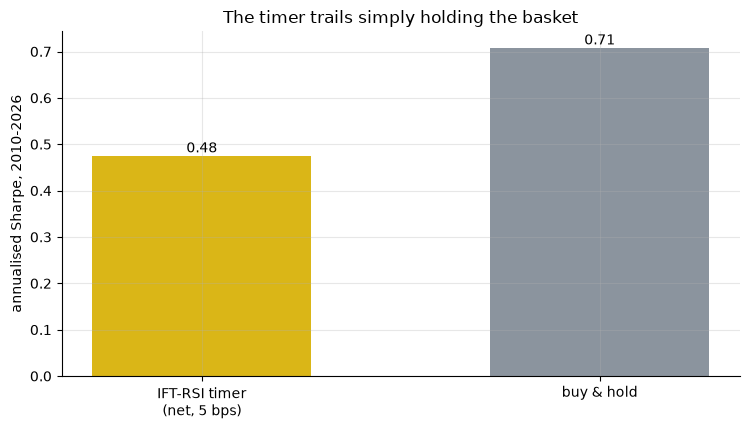

timer net Sharpe 0.48  vs buy-and-hold 0.71


In [5]:
if HAVE_REAL:
    tm = st.timer_with_costs(REAL, SIGNALS, 'ift_bull', 'ift_bear', cost_bps=5.0)
    net, bh = tm['sharpe_net'], tm['sharpe_bh']
else:
    net, bh = R['tm_sharpe5'], R['bh_sharpe']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['IFT-RSI timer\n(net, 5 bps)', 'buy & hold'], [net, bh], color=[AMBER, GREY], width=.55)
for i, v in enumerate([net, bh]): ax.annotate(f'{v:.2f}', (i, v), ha='center', va='bottom')
ax.set_ylabel('annualised Sharpe, 2010-2026')
ax.set_title('The timer trails simply holding the basket')
plt.tight_layout(); plt.show()
print(f'timer net Sharpe {net:.2f}  vs buy-and-hold {bh:.2f}')

Net Sharpe **0.48** against buy-and-hold's **0.71** — unsurprising given the timer is flat **52%** of the time during one of the strongest bull markets on record, but it also barely beats a coin-flip timer with the same exposure (z = +1.27, not certified). Nothing here clears the bar to trade.

## 5 · The verdict

- **Signal — None.** No horizon shows a certified edge; the closest call points the wrong way, and 97% of random entries beat the real signal.
- **Tradability — Mirage.** The costed timer trails buy-and-hold and barely edges out a random-exposure coin flip.
- **"Sharper than plain RSI(2/14)"? — Busted.** The fancier transform performs worse than the simplest baseline in the identical test.

## 6 · Going further 🚪

- **The general lesson.** A bounded, visually decisive oscillator is not automatically a *better-informed* one — Ehlers' transform reshapes RSI's distribution, it doesn't add new information to it. The same caution applies to every other "Fisherized" indicator in his toolbox.
- **Where it might still matter.** As a *filter* alongside a real signal (thin evidence either way here) rather than a standalone entry rule — untested by this study, a natural next step.
- **Sibling studies:** the [plain Fisher Transform on price](../../183-fisher-transform/) (proven mathematically redundant with the raw crossover), [Connors' RSI(2)](../../75-knee-jerk/) (the desk's real RSI-family signal), [Stochastic-RSI](../../428-stochastic-rsi/) (a different stacked transform, also a non-result) and [RSI divergence](../../669-rsi-divergence/) (a structural pattern, also a non-result) — four different ways to dress up RSI, four honest "no"s.

*Think the Inverse Fisher Transform earns its keep somewhere this test missed — a different asset class, a volatility regime, a filter role? Show a net, certifiable edge after costs, then we'll talk.*